# Dataset 1 — Day 41 Forecasting Workflow

| Target Day | Note |
|---|---|
| Day 41 | 41st chronological day (final day) — forecast target |

All heavy logic lives under `src/`. This notebook only calls functions.

**Flow**
1. Imports
2. Load Dataset 1 and sort it
3. Build matrix, train LSTM & Transformer, then forecast Day 41
   (using Day 40 as input) and compute ionospheric delays
4. Plots — LSTM/Transformer loss curves, actual vs predicted (LSTM & Transformer),
   L1+L5 combined ionospheric delay, all for Day 41
5. Event-threshold metrics (3 m / 8 m / 15 m) for LSTM & Transformer, L1 & L5,
   plus a summary metrics table — all for Day 41


---
### Imports

In [1]:
import torch
import numpy as np
import pandas as pd

from src.preprocessing.sort_tec_data import build_sorted_dataset
from src.preprocessing.dataset import prepare_dataset
from src.configs.config import (
    BASE_DIR_1, OUTPUT_DIR_1, PLOTS_DIR_1, GENERATED_PLOTS_DIR,
    F_L1, F_L5,
    EVENT_THRESHOLD_PERCENTILE, DELAY_EVENT_THRESHOLDS_M,
    get_date_label,
)
from src.training.lstm_training import train_lstm
from src.training.transformer_training import train_transformer
from src.plots.loss_plots import plot_lstm_loss, plot_transformer_loss
from src.plots.prediction_plots import plot_lstm_prediction, plot_transformer_prediction
from src.plots.delay_plots import (
    plot_lstm_delay_l1_l5_combined,
    plot_transformer_delay_l1_l5_combined,
)
from src.utils.iono_delay import delay_metrics, tec_to_iono_delay, compute_all_delays
from src.utils.save_results import save_delay_csv
from src.utils.metrics import (
    rmse,
    pearson_correlation,
    probability_of_detection,
    critical_success_index,
    f1_score,
    false_alarm_ratio,
)

# This notebook always targets Dataset 1, Day 41.
DATASET_NO = 1
TARGET_DAY = 41


---
# Dataset 1 — Day 41 Forecasting Workflow
---

### 1. Base Directory and Output Setup — Dataset 1

In [2]:
print(f"Base directory 1  : {BASE_DIR_1}")
print(f"Output directory 1: {OUTPUT_DIR_1}")
print(f"Target day         : {TARGET_DAY}")

Base directory 1  : c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1
Output directory 1: c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet
Target day         : 41


### 2. Creating Sorted TEC Dataset — Dataset 1
```text
Process the raw per-satellite folders and create one sorted CSV per folder
containing the maximum TEC value for each minute.
Returns: Number of output CSV files written.
```

In [3]:
written_files_1 = build_sorted_dataset(1)

print("TEC data sorting completed — Dataset 1.")
print(f"Number of output CSV files written: {written_files_1}")
print(f"Saved sorted CSV files to: {OUTPUT_DIR_1}")

TEC data sorting completed — Dataset 1.
Number of output CSV files written: 41
Saved sorted CSV files to: c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet


#### QUICK SANITY CHECK — Dataset 1
> Print first 6 lines of the first output file

In [4]:
sample_file_1 = OUTPUT_DIR_1 / "iisc1290_TECU_sorted.csv"
if sample_file_1.exists():
    with sample_file_1.open("r", newline="", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 5:
                break
else:
    print(f"Sample file not found: {sample_file_1}")

Time(UTC),TEC(TECU)
09-05-23 00:00,42.390972
09-05-23 00:01,51.206161
09-05-23 00:02,32.852289
09-05-23 00:03,34.870453
09-05-23 00:04,39.373245


### 3. Data Loading and Preprocessing — Dataset 1
```text
Loads sorted CSVs into a (days x minutes) numpy matrix,
builds supervised input/target pairs, and
normalises using training stats only.
```

In [5]:
X_train_1, y_train_1, X_val_1, y_val_1, stats_1, daily_matrix_1, daily_files_1 = prepare_dataset(1)

print(f"X_train : {X_train_1.shape}   y_train : {y_train_1.shape}")
print(f"X_val   : {X_val_1.shape}     y_val   : {y_val_1.shape}")
print(f"Norm stats : {stats_1}")

X_train : (29, 1440, 1)   y_train : (29, 1440, 1)
X_val   : (11, 1440, 1)     y_val   : (11, 1440, 1)
Norm stats : {'x_mean': 87.88667297363281, 'x_std': 45.894798288808595, 'y_mean': 86.92459106445312, 'y_std': 45.30130768822266}


### 4. LSTM Training Workflow — Dataset 1: Day 41 Forecast

> Dataset consists of 41 chronologically sorted TEC files.

```text
Training Set
------------
Input  : Days  1-29
Target : Days  2-30

Validation Set
--------------
Input  : Days 30-40
Target : Days 31-41

Forecast
--------
Input  : Day 40
Output : Day 41
```

In [6]:
lstm_model_1, lstm_history_1 = train_lstm(X_train_1, y_train_1, X_val_1, y_val_1)

Epoch 1/50 — loss: 0.970071 — val_loss: 0.703141
Epoch 2/50 — loss: 0.796376 — val_loss: 0.484105
Epoch 3/50 — loss: 0.379775 — val_loss: 0.139985
Epoch 4/50 — loss: 0.206873 — val_loss: 0.170383
Epoch 5/50 — loss: 0.157360 — val_loss: 0.136358
Epoch 6/50 — loss: 0.162006 — val_loss: 0.129844
Epoch 7/50 — loss: 0.146071 — val_loss: 0.134694
Epoch 8/50 — loss: 0.148146 — val_loss: 0.128769
Epoch 9/50 — loss: 0.141884 — val_loss: 0.126743
Epoch 10/50 — loss: 0.142981 — val_loss: 0.124715
Epoch 11/50 — loss: 0.134841 — val_loss: 0.125377
Epoch 12/50 — loss: 0.138120 — val_loss: 0.117390
Epoch 13/50 — loss: 0.129662 — val_loss: 0.117523
Epoch 14/50 — loss: 0.130526 — val_loss: 0.114831
Epoch 15/50 — loss: 0.134959 — val_loss: 0.116569
Epoch 16/50 — loss: 0.126524 — val_loss: 0.116000
Epoch 17/50 — loss: 0.135709 — val_loss: 0.118328
Epoch 18/50 — loss: 0.125984 — val_loss: 0.119945
Epoch 19/50 — loss: 0.124353 — val_loss: 0.115734
Epoch 20/50 — loss: 0.129371 — val_loss: 0.115576
Epoch 21/

### 5. LSTM Loss and Validation Curve — Dataset 1

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\loss_LSTM_dataset1.png


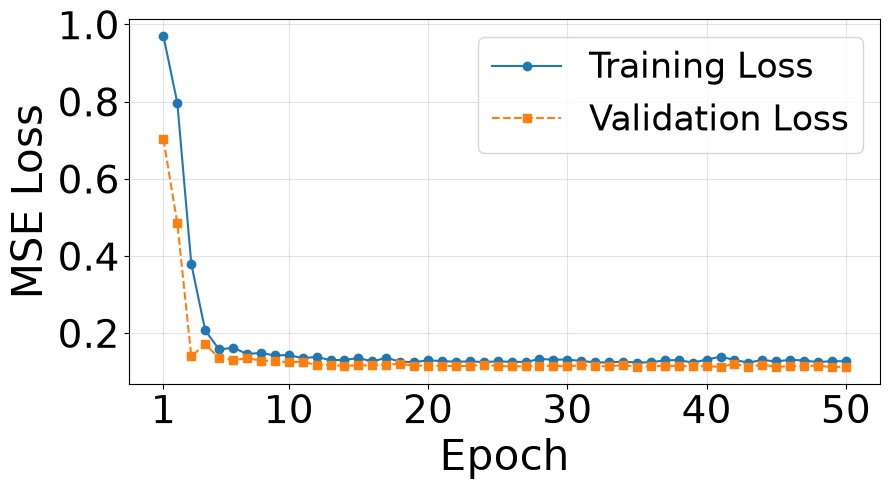

Final train loss : 0.126803
Final val   loss : 0.113233


In [7]:
plot_lstm_loss(lstm_history_1, dataset_label="dataset1", output_dir=str(PLOTS_DIR_1))

### 6. Transformer Training Workflow — Dataset 1: Day 41 Forecast

In [8]:
transformer_model_1, transformer_history_1 = train_transformer(X_train_1, y_train_1, X_val_1, y_val_1)

[Transformer] Training on: cpu
TECTransformerEncoder(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (output_proj): Linear(in_features=64, 

c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\src\models\transformer_model.py:101: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch   1/50 | loss: 2.577085 | val_loss: 2.360261 | lr: 1.14e-05
Epoch   2/50 | loss: 2.481625 | val_loss: 2.054646 | lr: 2.29e-05
Epoch   3/50 | loss: 2.238166 | val_loss: 1.708990 | lr: 3.43e-05
Epoch   4/50 | loss: 1.943856 | val_loss: 1.373218 | lr: 4.57e-05
Epoch   5/50 | loss: 1.642516 | val_loss: 1.052700 | lr: 5.71e-05
Epoch   6/50 | loss: 1.299940 | val_loss: 0.768088 | lr: 6.86e-05
Epoch   7/50 | loss: 1.001292 | val_loss: 0.557244 | lr: 8.00e-05
Epoch   8/50 | loss: 0.774300 | val_loss: 0.408954 | lr: 9.14e-05
Epoch   9/50 | loss: 0.609417 | val_loss: 0.296289 | lr: 1.00e-04
Epoch  10/50 | loss: 0.486653 | val_loss: 0.215877 | lr: 9.97e-05
Epoch  11/50 | loss: 0.402370 | val_loss: 0.172543 | lr: 9.90e-05
Epoch  12/50 | loss: 0.347721 | val_loss: 0.157285 | lr: 9.79e-05
Epoch  13/50 | loss: 0.328952 | val_loss: 0.145738 | lr: 9.64e-05
Epoch  14/50 | loss: 0.294915 | val_loss: 0.139844 | lr: 9.46e-05
Epoch  15/50 | loss: 0.286239 | val_loss: 0.132765 | lr: 9.24e-05
Epoch  16/

### 7. Transformer Loss and Validation Curve — Dataset 1

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\loss_transformer_dataset1.png


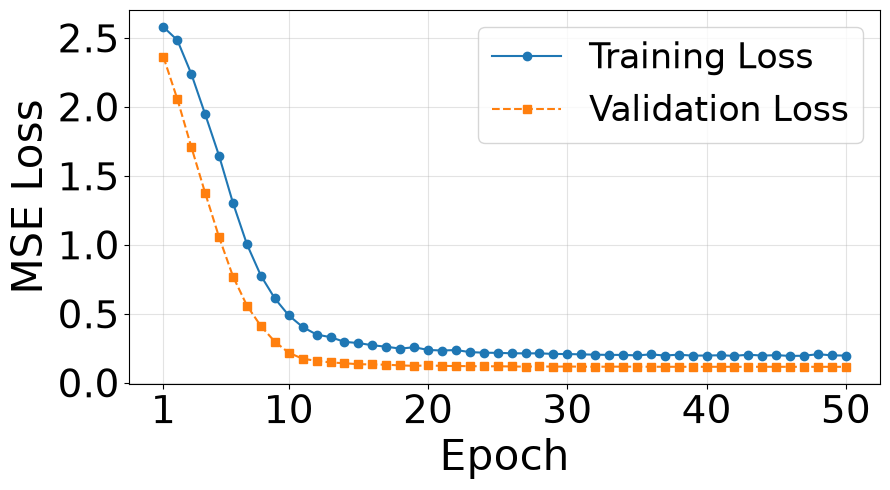

Final train loss : 0.195501
Final val   loss : 0.113853


In [9]:
plot_transformer_loss(transformer_history_1, dataset_label="dataset1", output_dir=str(PLOTS_DIR_1))

### 8. Forecast Day 41 — Dataset 1

Day 40's TEC is fed in as input and both trained models forecast Day 41.
Actual, LSTM-predicted, and Transformer-predicted TEC (plus their L1
ionospheric delays) are collected into `result_1` for use by every
plotting/metrics cell below.

In [10]:
x_mean_1, x_std_1 = stats_1["x_mean"], stats_1["x_std"]
y_mean_1, y_std_1 = stats_1["y_mean"], stats_1["y_std"]

device = next(lstm_model_1.parameters()).device
lstm_model_1.eval()
transformer_model_1.eval()

day40_raw_1 = daily_matrix_1[TARGET_DAY - 2]   # Day 40 -> predicts Day 41
actual41_1  = daily_matrix_1[TARGET_DAY - 1]

input_norm_1 = ((day40_raw_1 - x_mean_1) / x_std_1)[np.newaxis, ..., np.newaxis]
src_1 = torch.tensor(input_norm_1, dtype=torch.float32).to(device)

with torch.no_grad():
    lstm_pred_norm_1  = lstm_model_1(src_1).squeeze().cpu().numpy()
    trans_pred_norm_1 = transformer_model_1(src_1).squeeze().cpu().numpy()

lstm_pred41_1  = lstm_pred_norm_1  * y_std_1 + y_mean_1
trans_pred41_1 = trans_pred_norm_1 * y_std_1 + y_mean_1

date_label_1 = get_date_label(DATASET_NO, TARGET_DAY)

result_1 = dict(
    actual=actual41_1,
    lstm_pred=lstm_pred41_1,
    trans_pred=trans_pred41_1,
    date_label=date_label_1,
    iono_actual=tec_to_iono_delay(actual41_1),
    iono_lstm=tec_to_iono_delay(lstm_pred41_1),
    iono_trans=tec_to_iono_delay(trans_pred41_1),
)

print(f"Forecast day: {TARGET_DAY}  ({date_label_1 or 'date unknown'})  -- done")

Forecast day: 41  (date unknown)  -- done


### 9. Actual vs Predicted TEC Plots — Dataset 1, Day 41

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_LSTM_day41_dataset1.png


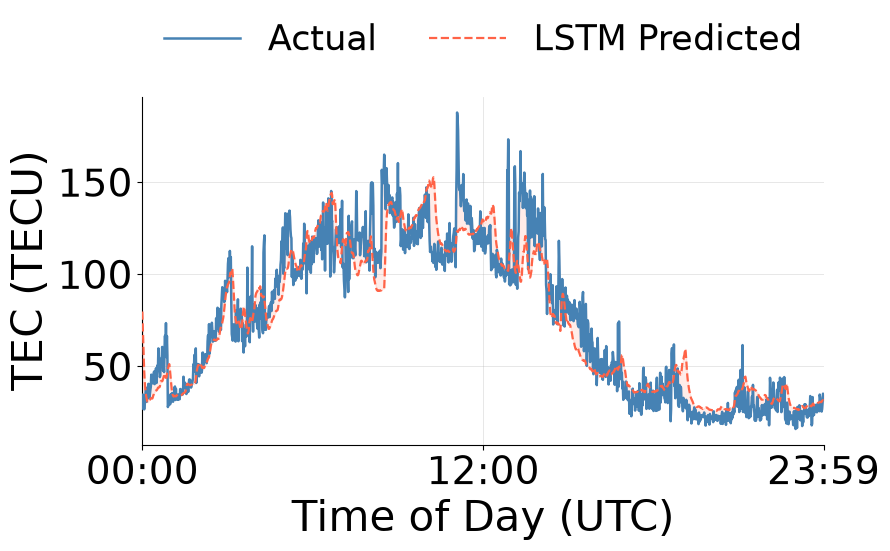

LSTM Day-41 RMSE : 15.3465 TECU
LSTM Day-41 MAE  : 11.0779 TECU
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\actual_vs_predicted_transformer_day41_dataset1.png


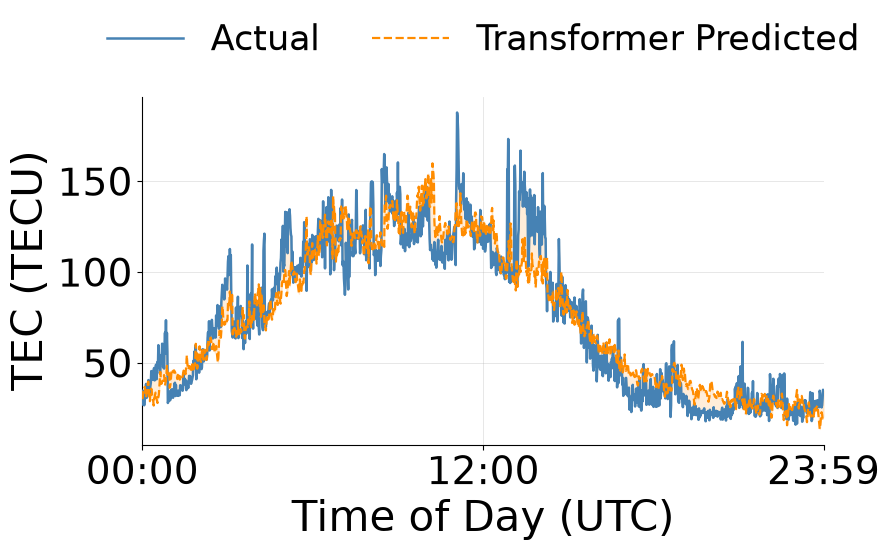

Transformer Day-41 RMSE : 14.8659 TECU
Transformer Day-41 MAE  : 10.9083 TECU


In [11]:
lstm_rmse_1, lstm_mae_1 = plot_lstm_prediction(
    result_1["actual"], result_1["lstm_pred"], target_day=TARGET_DAY, dataset_label=f"dataset{DATASET_NO}",
    date_label=result_1["date_label"], output_dir=str(PLOTS_DIR_1),
)
trans_rmse_1, trans_mae_1 = plot_transformer_prediction(
    result_1["actual"], result_1["trans_pred"], target_day=TARGET_DAY, dataset_label=f"dataset{DATASET_NO}",
    date_label=result_1["date_label"], output_dir=str(PLOTS_DIR_1),
)

tec_metrics_1 = dict(
    lstm_rmse=lstm_rmse_1, lstm_mae=lstm_mae_1,
    trans_rmse=trans_rmse_1, trans_mae=trans_mae_1,
)

### 10. Model Comparison Summary for Day 41 Forecast — Dataset 1

In [12]:
print("=" * 45)
print(f"{'Model':<15} {'RMSE (TECU)':>12} {'MAE (TECU)':>12}")
print("-" * 45)
print(f"{'LSTM':<15} {lstm_rmse_1:>12.4f} {lstm_mae_1:>12.4f}")
print(f"{'Transformer':<15} {trans_rmse_1:>12.4f} {trans_mae_1:>12.4f}")
print("=" * 45)

Model            RMSE (TECU)   MAE (TECU)
---------------------------------------------
LSTM                 15.3465      11.0779
Transformer          14.8659      10.9083


### 11. L1 + L5 Combined Ionospheric Delay Plots — Dataset 1, Day 41

LSTM L1 — RMSE: 2.49234 m   MAE: 1.79910 m
LSTM L5 — RMSE: 4.46943 m   MAE: 3.22628 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_LSTM_L1_L5_combined_day41_dataset1.png


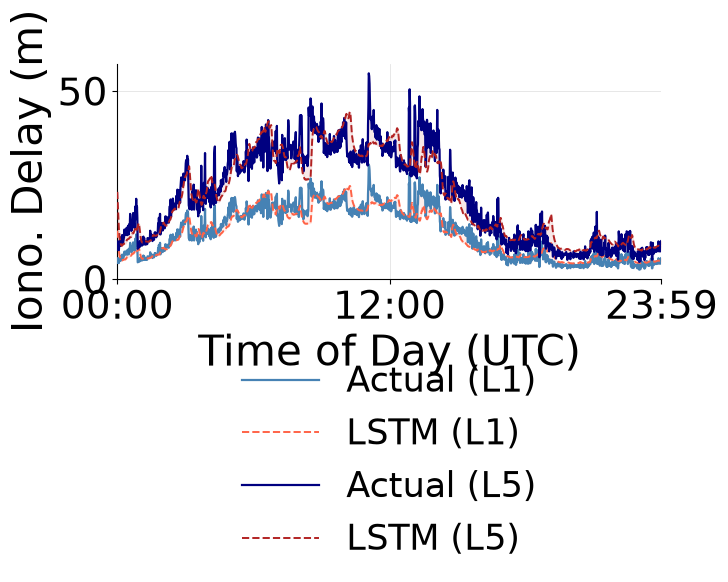

Transformer L1 — RMSE: 2.41429 m   MAE: 1.77157 m
Transformer L5 — RMSE: 4.32948 m   MAE: 3.17690 m
Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\dataset1_plots\ionospheric_delay_transformer_L1_L5_combined_day41_dataset1.png


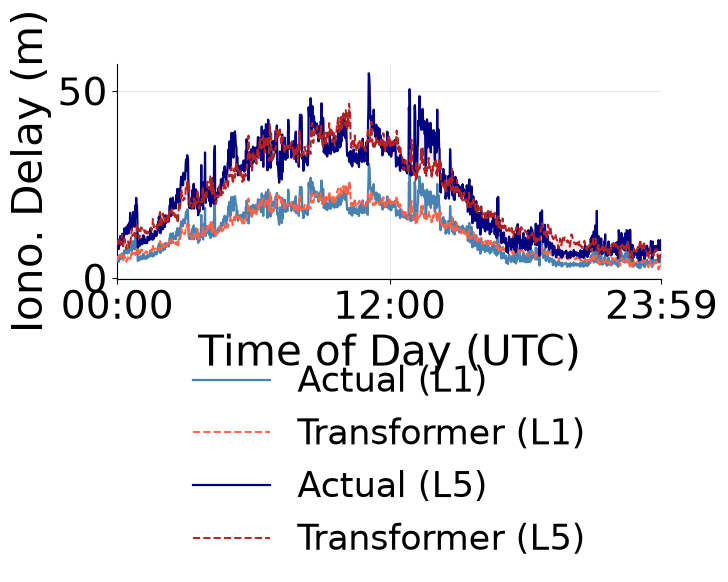

In [13]:
plot_lstm_delay_l1_l5_combined(
    result_1["actual"], result_1["lstm_pred"], target_day=TARGET_DAY, dataset_label=f"dataset{DATASET_NO}",
    date_label=result_1["date_label"], output_dir=str(PLOTS_DIR_1),
)
plot_transformer_delay_l1_l5_combined(
    result_1["actual"], result_1["trans_pred"], target_day=TARGET_DAY, dataset_label=f"dataset{DATASET_NO}",
    date_label=result_1["date_label"], output_dir=str(PLOTS_DIR_1),
)

### 12. Delay Error Metrics (L1, vertical) — Dataset 1, Day 41

In [14]:
print(f"Ionospheric Delay Error (L1, vertical) — Day {TARGET_DAY} ({result_1['date_label'] or 'date unknown'}) — Dataset {DATASET_NO}")
print("=" * 70)
delay_metrics("LSTM",        result_1["iono_lstm"],  result_1["iono_actual"])
delay_metrics("Transformer", result_1["iono_trans"], result_1["iono_actual"])

Ionospheric Delay Error (L1, vertical) — Day 41 (date unknown) — Dataset 1
LSTM             RMSE = 2.49234 m   MAE = 1.79910 m   Bias = -0.11491 m
Transformer      RMSE = 2.41429 m   MAE = 1.77157 m   Bias = -0.07010 m


{'name': 'Transformer',
 'rmse': 2.4142942428588867,
 'mae': 1.771565556526184,
 'bias': -0.07009623944759369}

### 13. Save Forecast Output CSV — Dataset 1, Day 41

In [15]:
save_delay_csv(
    result_1["actual"], result_1["lstm_pred"], result_1["trans_pred"],
    output_dir=OUTPUT_DIR_1,
    filename=f"day{TARGET_DAY}_ionospheric_delay.csv",
)

Delay table saved → c:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet\day41_ionospheric_delay.csv


---
## Event-Threshold Metrics — Dataset 1, Day 41

High-TEC threshold (65th percentile of training targets), then POD / CSI / F1 / FAR
at L1 and L5 ionospheric-delay thresholds (3 m / 8 m / 15 m) for Day 41.

In [16]:
storm_threshold_1 = float(
    np.percentile(daily_matrix_1[1:30], EVENT_THRESHOLD_PERCENTILE)
)
print(
    f"High-TEC threshold ({EVENT_THRESHOLD_PERCENTILE:.0f}th percentile): "
    f"{storm_threshold_1:.2f} TECU"
)

High-TEC threshold (65th percentile): 110.06 TECU


In [17]:
lstm_rmse_metric_1        = rmse(lstm_pred41_1, actual41_1)
transformer_rmse_metric_1 = rmse(trans_pred41_1, actual41_1)

print(f"LSTM RMSE:        {lstm_rmse_metric_1:.4f} TECU")
print(f"Transformer RMSE: {transformer_rmse_metric_1:.4f} TECU")

LSTM RMSE:        15.3465 TECU
Transformer RMSE: 14.8659 TECU


In [18]:
lstm_correlation_1        = pearson_correlation(lstm_pred41_1, actual41_1)
transformer_correlation_1 = pearson_correlation(trans_pred41_1, actual41_1)

print("Dataset 1 — Day 41")
print(f"LSTM correlation:        {lstm_correlation_1:.4f}")
print(f"Transformer correlation: {transformer_correlation_1:.4f}")

Dataset 1 — Day 41
LSTM correlation:        0.9298
Transformer correlation: 0.9342


In [19]:
lstm_pod_1        = probability_of_detection(lstm_pred41_1, actual41_1, threshold=storm_threshold_1)
transformer_pod_1 = probability_of_detection(trans_pred41_1, actual41_1, threshold=storm_threshold_1)

print("Dataset 1 — Day 41 POD")
print(f"LSTM POD:        {lstm_pod_1:.4f}")
print(f"Transformer POD: {transformer_pod_1:.4f}")

Dataset 1 — Day 41 POD
LSTM POD:        0.7362
Transformer POD: 0.7602


In [20]:
lstm_csi_1        = critical_success_index(lstm_pred41_1, actual41_1, threshold=storm_threshold_1)
transformer_csi_1 = critical_success_index(trans_pred41_1, actual41_1, threshold=storm_threshold_1)

print("Dataset 1 — Day 41 CSI")
print(f"LSTM CSI:        {lstm_csi_1:.4f}")
print(f"Transformer CSI: {transformer_csi_1:.4f}")

Dataset 1 — Day 41 CSI
LSTM CSI:        0.6165
Transformer CSI: 0.6353


In [21]:
lstm_f1_1        = f1_score(lstm_pred41_1, actual41_1, threshold=storm_threshold_1)
transformer_f1_1 = f1_score(trans_pred41_1, actual41_1, threshold=storm_threshold_1)

print("Dataset 1 — Day 41 F1 score")
print(f"LSTM F1:        {lstm_f1_1:.4f}")
print(f"Transformer F1: {transformer_f1_1:.4f}")

Dataset 1 — Day 41 F1 score
LSTM F1:        0.7627
Transformer F1: 0.7770


In [22]:
lstm_far_1        = false_alarm_ratio(lstm_pred41_1, actual41_1, threshold=storm_threshold_1)
transformer_far_1 = false_alarm_ratio(trans_pred41_1, actual41_1, threshold=storm_threshold_1)

print("Dataset 1 — Day 41 FAR")
print(f"LSTM FAR:        {lstm_far_1:.4f}")
print(f"Transformer FAR: {transformer_far_1:.4f}")

Dataset 1 — Day 41 FAR
LSTM FAR:        0.2088
Transformer FAR: 0.2055


In [23]:
def print_event_counts(name, actual, lstm_pred, trans_pred, threshold):
    print(f"\n{name}")
    print(f"Threshold: {threshold:.2f} TECU")
    print(f"Actual events        : {np.sum(actual >= threshold)}")
    print(f"LSTM predicted       : {np.sum(lstm_pred >= threshold)}")
    print(f"Transformer predicted: {np.sum(trans_pred >= threshold)}")

print_event_counts(
    "Dataset 1 — Day 41",
    actual41_1, lstm_pred41_1, trans_pred41_1, storm_threshold_1,
)


Dataset 1 — Day 41
Threshold: 110.06 TECU
Actual events        : 417
LSTM predicted       : 388
Transformer predicted: 399


In [24]:
# L1 ionospheric-delay event thresholds — Day 41
delay_event_inputs_1 = {
    "Dataset 1": (result_1["iono_actual"], result_1["iono_lstm"], result_1["iono_trans"]),
}

for threshold_m in DELAY_EVENT_THRESHOLDS_M:
    print(f"\n{'=' * 70}")
    print(f"L1 ionospheric-delay event threshold: {threshold_m:.0f} m")

    for dataset_name, (actual_delay, lstm_delay, trans_delay) in delay_event_inputs_1.items():
        print(f"\n{dataset_name} — Day 41")

        for model_name, predicted_delay in (
            ("LSTM", lstm_delay),
            ("Transformer", trans_delay),
        ):
            pod = probability_of_detection(predicted_delay, actual_delay, threshold=threshold_m)
            csi = critical_success_index(predicted_delay, actual_delay, threshold=threshold_m)
            f1  = f1_score(predicted_delay, actual_delay, threshold=threshold_m)
            far = false_alarm_ratio(predicted_delay, actual_delay, threshold=threshold_m)

            print(
                f"{model_name:<12} POD: {pod:.4f} | "
                f"CSI: {csi:.4f} | F1: {f1:.4f} | FAR: {far:.4f}"
            )


L1 ionospheric-delay event threshold: 3 m

Dataset 1 — Day 41
LSTM         POD: 1.0000 | CSI: 0.9931 | F1: 0.9965 | FAR: 0.0069
Transformer  POD: 0.9937 | CSI: 0.9868 | F1: 0.9934 | FAR: 0.0070

L1 ionospheric-delay event threshold: 8 m

Dataset 1 — Day 41
LSTM         POD: 0.9269 | CSI: 0.8908 | F1: 0.9423 | FAR: 0.0419
Transformer  POD: 0.9696 | CSI: 0.9289 | F1: 0.9631 | FAR: 0.0433

L1 ionospheric-delay event threshold: 15 m

Dataset 1 — Day 41
LSTM         POD: 0.9109 | CSI: 0.8827 | F1: 0.9377 | FAR: 0.0339
Transformer  POD: 0.9109 | CSI: 0.8988 | F1: 0.9467 | FAR: 0.0145


In [25]:
# L5 ionospheric-delay event thresholds — Day 41
iono_actual41_1_L5 = tec_to_iono_delay(actual41_1, frequency=F_L5)
iono_lstm41_1_L5   = tec_to_iono_delay(lstm_pred41_1, frequency=F_L5)
iono_trans41_1_L5  = tec_to_iono_delay(trans_pred41_1, frequency=F_L5)

delay_event_inputs_L5_1 = {
    "Dataset 1": (iono_actual41_1_L5, iono_lstm41_1_L5, iono_trans41_1_L5),
}

for threshold_m in DELAY_EVENT_THRESHOLDS_M:
    print(f"\n{'=' * 70}")
    print(f"L5 ionospheric-delay event threshold: {threshold_m:.0f} m")
    for dataset_name, (actual_delay, lstm_delay, trans_delay) in delay_event_inputs_L5_1.items():
        print(f"\n{dataset_name} — Day 41")
        for model_name, predicted_delay in (("LSTM", lstm_delay), ("Transformer", trans_delay)):
            pod = probability_of_detection(predicted_delay, actual_delay, threshold=threshold_m)
            csi = critical_success_index(predicted_delay, actual_delay, threshold=threshold_m)
            f1  = f1_score(predicted_delay, actual_delay, threshold=threshold_m)
            far = false_alarm_ratio(predicted_delay, actual_delay, threshold=threshold_m)
            print(f"{model_name:<12} POD: {pod:.4f} | CSI: {csi:.4f} | F1: {f1:.4f} | FAR: {far:.4f}")


L5 ionospheric-delay event threshold: 3 m

Dataset 1 — Day 41
LSTM         POD: 1.0000 | CSI: 1.0000 | F1: 1.0000 | FAR: 0.0000
Transformer  POD: 1.0000 | CSI: 1.0000 | F1: 1.0000 | FAR: 0.0000

L5 ionospheric-delay event threshold: 8 m

Dataset 1 — Day 41
LSTM         POD: 0.9951 | CSI: 0.8856 | F1: 0.9393 | FAR: 0.1105
Transformer  POD: 0.9599 | CSI: 0.8567 | F1: 0.9228 | FAR: 0.1114

L5 ionospheric-delay event threshold: 15 m

Dataset 1 — Day 41
LSTM         POD: 0.9261 | CSI: 0.9052 | F1: 0.9502 | FAR: 0.0243
Transformer  POD: 0.9700 | CSI: 0.9200 | F1: 0.9584 | FAR: 0.0530


In [26]:
# RMSE & Correlation on Ionospheric Delay — L1 & L5, LSTM vs Transformer (Dataset 1, Day 41)
freqs = {"L1": F_L1, "L5": F_L5}

actual_tec_1, lstm_tec_1, trans_tec_1 = actual41_1, lstm_pred41_1, trans_pred41_1

delay_rows_1 = []

for freq_label, freq_hz in freqs.items():
    actual_delay, lstm_delay, trans_delay = compute_all_delays(
        actual_tec_1, lstm_tec_1, trans_tec_1, frequency=freq_hz
    )

    for model_name, pred_delay in (
        ("LSTM", lstm_delay),
        ("Transformer", trans_delay),
    ):
        delay_rmse = rmse(pred_delay, actual_delay)
        delay_corr = pearson_correlation(pred_delay, actual_delay)

        delay_rows_1.append({
            "Frequency":   freq_label,
            "Model":       model_name,
            "RMSE (m)":    delay_rmse,
            "Correlation": delay_corr,
        })

        print(
            f"{freq_label:<3} | {model_name:<12} "
            f"| RMSE: {delay_rmse:.4f} m | Corr: {delay_corr:.4f}"
        )

iono_delay_metrics_table_1 = pd.DataFrame(delay_rows_1).round(4)
iono_delay_metrics_table_1

L1  | LSTM         | RMSE: 2.4923 m | Corr: 0.9298
L1  | Transformer  | RMSE: 2.4143 m | Corr: 0.9342
L5  | LSTM         | RMSE: 4.4694 m | Corr: 0.9298
L5  | Transformer  | RMSE: 4.3295 m | Corr: 0.9342


,Frequency,Model,RMSE (m),Correlation
0,L1,LSTM,2.4923,0.9298
1,L1,Transformer,2.4143,0.9342
2,L5,LSTM,4.4694,0.9298
3,L5,Transformer,4.3295,0.9342


---
## Summary — Metrics Table (Dataset 1, Day 41)
```text
Consolidates every metric computed above (RMSE, Correlation, POD, CSI,
F1 score, FAR) for both models (LSTM, Transformer) into a single
comparison table, and writes it to CSV for the paper.
```

In [27]:
metrics_summary_1 = pd.DataFrame({
    "Dataset": ["Dataset 1", "Dataset 1"],
    "Model":   ["LSTM", "Transformer"],
    "RMSE (TECU)": [
        lstm_rmse_metric_1, transformer_rmse_metric_1,
    ],
    "Correlation": [
        lstm_correlation_1, transformer_correlation_1,
    ],
    "POD": [
        lstm_pod_1, transformer_pod_1,
    ],
    "CSI": [
        lstm_csi_1, transformer_csi_1,
    ],
    "F1 Score": [
        lstm_f1_1, transformer_f1_1,
    ],
    "FAR": [
        lstm_far_1, transformer_far_1,
    ],
}).round(4)

print("=" * 100)
print("Day 41 Forecast — Summary Metrics Table (Dataset 1)")
print("=" * 100)
print(metrics_summary_1.to_string(index=False))

summary_csv_path_1 = GENERATED_PLOTS_DIR / "metrics_summary_dataset1_day41.csv"
GENERATED_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
metrics_summary_1.to_csv(summary_csv_path_1, index=False)
print(f"\nSaved summary table to: {summary_csv_path_1}")

metrics_summary_1

Day 41 Forecast — Summary Metrics Table (Dataset 1)
  Dataset       Model  RMSE (TECU)  Correlation    POD    CSI  F1 Score    FAR
Dataset 1        LSTM      15.3465       0.9298 0.7362 0.6165    0.7627 0.2088
Dataset 1 Transformer      14.8659       0.9342 0.7602 0.6353    0.7770 0.2055

Saved summary table to: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\metrics_summary_dataset1_day41.csv


,Dataset,Model,RMSE (TECU),Correlation,POD,CSI,F1 Score,FAR
0,Dataset 1,LSTM,15.3465,0.9298,0.7362,0.6165,0.7627,0.2088
1,Dataset 1,Transformer,14.8659,0.9342,0.7602,0.6353,0.7770,0.2055
